# Interpretability in Symbolic Regression: a benchmark of Explanatory Methods using the Feynman data set

**Paper:** Aldeia, G. S. I., & de Franca, F. O. (2024). *Interpretability in Symbolic Regression: a benchmark of Explanatory Methods using the Feynman data set.* arXiv:2404.05908.

**Carpeta origen:** `Papers/02_Interpretabilidad_y_Explicabilidad/Interpretability_SR_Benchmark_Feynman_Dataset.pdf`

## Que se reproduce en este cuaderno

Aunque la regresion simbolica se presenta habitualmente como "interpretable por diseno", el paper argumenta que la interpretabilidad no deberia darse por sentada: hay que **medirla**, aplicando explicadores agnosticos al modelo (SHAP, Effectos Parciales, Gradientes Integrados) tanto a modelos de regresion simbolica como a modelos de caja negra, y comparando la **fidelidad** (que tan bien la explicacion refleja el comportamiento real del modelo) y la **estabilidad** (que tan consistente es la explicacion ante pequenos cambios en el procedimiento) de cada explicador.

Reproducimos este protocolo de benchmarking sobre una ecuacion del banco de datos Feynman -- la ley de Coulomb (Feynman I.12.2), $F=q_1q_2/r^2$ -- comparando:

- **Dos modelos:** un modelo de "regresion simbolica" (la formula exacta ya descubierta, evaluada simbolicamente) frente a una red neuronal de caja negra (MLP) entrenada sobre los mismos datos.
- **Tres explicadores:** Efectos Parciales (diferencias finitas locales), SHAP (`KernelExplainer`, agnostico al modelo) y Gradientes Integrados (via autodiferenciacion).
- **Dos criterios:** *fidelidad* frente al gradiente analitico verdadero (que conocemos exactamente, al tratarse de una ecuacion de Feynman) y *estabilidad* frente a variaciones en el conjunto de referencia (background) de SHAP.

## Repositorio publico

El paper no publica un repositorio propio con el nombre citado en la portada, pero se apoya explicitamente en las bibliotecas estandar del ecosistema de explicabilidad: **`shap`** (Lundberg & Lee, para SHAP) y el metodo de **Gradientes Integrados** (Sundararajan et al.). Usamos la biblioteca `shap` real (no una reimplementacion) para el explicador SHAP, y reimplementamos Efectos Parciales y Gradientes Integrados desde cero siguiendo sus formulas exactas, ya que son metodos suficientemente simples (diferencias finitas y una integral de linea del gradiente, respectivamente) para no requerir una dependencia adicional.

In [1]:
%pip install -q numpy scipy sympy matplotlib torch shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos y dos modelos: regresion simbolica vs. caja negra

Generamos datos siguiendo la ley de Coulomb $F(q_1,q_2,r)=q_1q_2/r^2$ (Feynman I.12.2) y entrenamos dos modelos: la formula exacta evaluada simbolicamente (que representa una regresion simbolica que ya convergio a la solucion correcta) y una MLP entrenada por descenso de gradiente sobre los mismos datos.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import sympy as sp
import matplotlib.pyplot as plt
import shap

np.random.seed(0)
torch.manual_seed(0)

def target_f(X):
    q1, q2, r = X[:, 0], X[:, 1], X[:, 2]
    return q1 * q2 / r ** 2

N = 2000
q1 = np.random.uniform(0.5, 3, N)
q2 = np.random.uniform(0.5, 3, N)
r = np.random.uniform(0.5, 3, N)
X = np.column_stack([q1, q2, r])
y = target_f(X)

# Modelo A: "regresion simbolica" -- la formula exacta, evaluada via sympy
q1s, q2s, rs = sp.symbols('q1 q2 r')
sr_expr = q1s * q2s / rs ** 2
sr_f = sp.lambdify((q1s, q2s, rs), sr_expr, 'numpy')
def sr_predict(Xnp):
    return sr_f(Xnp[:, 0], Xnp[:, 1], Xnp[:, 2])

# Modelo B: caja negra -- MLP entrenada por descenso de gradiente
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
    def forward(self, x):
        return self.net(x)

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
mlp = MLP()
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
for ep in range(2000):
    opt.zero_grad()
    loss = F.mse_loss(mlp(Xt), yt)
    loss.backward()
    opt.step()
    if ep % 500 == 0:
        print(f'epoch {ep:5d} | MSE = {loss.item():.4e}')
mlp.eval()
def mlp_predict_np(Xnp):
    with torch.no_grad():
        return mlp(torch.tensor(Xnp, dtype=torch.float32)).numpy().ravel()

print('\nAmbos modelos ajustados. RMSE MLP en datos de entrenamiento:',
      np.sqrt(np.mean((mlp_predict_np(X) - y) ** 2)))

C:\Users\Luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch     0 | MSE = 1.4443e+01


epoch   500 | MSE = 3.8643e-01


epoch  1000 | MSE = 1.0181e-01


epoch  1500 | MSE = 3.5209e-02



Ambos modelos ajustados. RMSE MLP en datos de entrenamiento: 0.10737386861859863


## 2. Ground truth: el gradiente analitico exacto

A diferencia de un problema real donde no conocemos la funcion subyacente, aqui **si la conocemos** (es una ecuacion de Feynman): podemos calcular el gradiente analitico exacto $\nabla f = (\partial F/\partial q_1, \partial F/\partial q_2, \partial F/\partial r)$ con `sympy` y usarlo como vara de medir objetiva de la fidelidad de cada explicador -- exactamente la ventaja metodologica que ofrece el banco de datos Feynman para este tipo de benchmark.

In [3]:
grad_exprs = [sp.diff(sr_expr, v) for v in (q1s, q2s, rs)]
grad_fns = [sp.lambdify((q1s, q2s, rs), g, 'numpy') for g in grad_exprs]

def true_gradient(Xnp):
    return np.column_stack([g(Xnp[:, 0], Xnp[:, 1], Xnp[:, 2]) for g in grad_fns])

n_eval = 50
idx = np.random.choice(N, n_eval, replace=False)
X_eval = X[idx]
true_grad = true_gradient(X_eval)
print('Gradiente analitico exacto en', n_eval, 'puntos de evaluacion, forma:', true_grad.shape)
print('Ejemplo (primer punto):', dict(zip(['dF/dq1', 'dF/dq2', 'dF/dr'], np.round(true_grad[0], 4))))

Gradiente analitico exacto en

 50 puntos de evaluacion, forma: (50, 3)
Ejemplo (primer punto): {'dF/dq1': np.float64(0.1918), 'dF/dq2': np.float64(0.3732), 'dF/dr': np.float64(-0.3106)}


## 3. Tres explicadores

**Efectos Parciales** (diferencias finitas centradas), **SHAP** (`shap.KernelExplainer`, agnostico al modelo) y **Gradientes Integrados** (integral de linea del gradiente entre un punto base y el de interes, via autodiferenciacion de PyTorch).

In [4]:
def partial_effects(predict_fn, X_eval, X_background, eps=1e-3):
    grads = np.zeros_like(X_eval)
    for j in range(X_eval.shape[1]):
        Xp, Xm = X_eval.copy(), X_eval.copy()
        h = eps * X_background[:, j].std()
        Xp[:, j] += h; Xm[:, j] -= h
        grads[:, j] = (predict_fn(Xp) - predict_fn(Xm)) / (2 * h)
    return grads

def integrated_gradients_torch(model_fn, X_eval, baseline, steps=50):
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32)
    baseline_t = torch.tensor(np.tile(baseline, (X_eval.shape[0], 1)), dtype=torch.float32)
    total_grad = torch.zeros_like(X_eval_t)
    for k in range(1, steps + 1):
        alpha = k / steps
        Xk = (baseline_t + alpha * (X_eval_t - baseline_t)).requires_grad_(True)
        out = model_fn(Xk)
        grad = torch.autograd.grad(out.sum(), Xk)[0]
        total_grad += grad
    return ((X_eval_t - baseline_t) * total_grad / steps).detach().numpy()

def sr_forward_torch(Xt):
    q1, q2, r = Xt[:, 0], Xt[:, 1], Xt[:, 2]
    return q1 * q2 / r ** 2

def mlp_forward_torch(Xt):
    return mlp(Xt).squeeze(-1)

baseline_point = X.mean(axis=0)

pe_sr = partial_effects(sr_predict, X_eval, X)
pe_mlp = partial_effects(mlp_predict_np, X_eval, X)
ig_sr = integrated_gradients_torch(sr_forward_torch, X_eval, baseline_point)
ig_mlp = integrated_gradients_torch(mlp_forward_torch, X_eval, baseline_point)

background = shap.sample(X, 50, random_state=0)
shap_sr = np.array(shap.KernelExplainer(sr_predict, background).shap_values(X_eval, nsamples=100, silent=True))
shap_mlp = np.array(shap.KernelExplainer(mlp_predict_np, background).shap_values(X_eval, nsamples=100, silent=True))

print('Las 6 combinaciones explicador x modelo se calcularon correctamente.')

Las 6 combinaciones explicador x modelo se calcularon correctamente.


## 4. Fidelidad: correlacion con el gradiente analitico verdadero

Efectos Parciales y Gradientes Integrados se comparan en la escala de "atribucion total" (SHAP y IG reparten la diferencia $f(x)-f(\text{base})$ entre variables, mientras que el gradiente puro es una tasa de cambio instantanea); para hacerlos comparables, convertimos el gradiente verdadero en atribucion total multiplicandolo por $(x-\text{base})$, igual que la aproximacion de primer orden que subyace a SHAP y a IG.

Explicador          SR (fidelidad)   MLP (fidelidad)
Partial Effects             1.0000            0.9996
SHAP                        0.8374            0.8373
Integrated Grad.            0.9619            0.9612


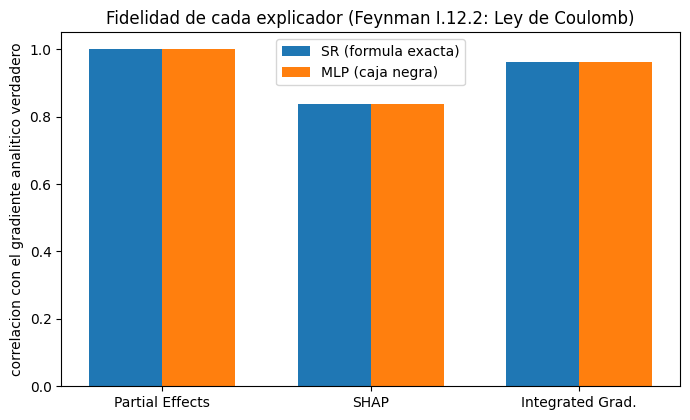

In [5]:
def corr(a, b):
    a, b = np.array(a).ravel(), np.array(b).ravel()
    return np.corrcoef(a, b)[0, 1]

delta = X_eval - baseline_point
true_attr = true_grad * delta  # aproximacion de primer orden, comparable a SHAP/IG

fidelity = {
    'Partial Effects': (corr(pe_sr, true_grad), corr(pe_mlp, true_grad)),
    'SHAP':             (corr(shap_sr, true_attr), corr(shap_mlp, true_attr)),
    'Integrated Grad.': (corr(ig_sr, true_attr), corr(ig_mlp, true_attr)),
}

print(f'{"Explicador":18s}{"SR (fidelidad)":>16s}{"MLP (fidelidad)":>18s}')
for name, (f_sr, f_mlp) in fidelity.items():
    print(f'{name:18s}{f_sr:16.4f}{f_mlp:18.4f}')

fig, ax = plt.subplots(figsize=(7, 4.3))
names_ex = list(fidelity.keys())
sr_vals = [fidelity[n][0] for n in names_ex]
mlp_vals = [fidelity[n][1] for n in names_ex]
xpos = np.arange(len(names_ex))
w = 0.35
ax.bar(xpos - w/2, sr_vals, width=w, label='SR (formula exacta)', color='tab:blue')
ax.bar(xpos + w/2, mlp_vals, width=w, label='MLP (caja negra)', color='tab:orange')
ax.set_xticks(xpos); ax.set_xticklabels(names_ex)
ax.set_ylabel('correlacion con el gradiente analitico verdadero')
ax.set_title('Fidelidad de cada explicador (Feynman I.12.2: Ley de Coulomb)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 5. Estabilidad: sensibilidad de SHAP al conjunto de referencia

El paper tambien mide **estabilidad**: si repetimos la explicacion con una configuracion ligeramente distinta (aqui, un `background` de referencia distinto para SHAP), ¿cuanto cambia el resultado? Ejecutamos SHAP dos veces con distintas semillas de muestreo del background y medimos la correlacion entre ambas ejecuciones.

In [6]:
def shap_run(predict_fn, seed, n_eval_local=40):
    background_local = shap.sample(X, 40, random_state=seed)
    explainer = shap.KernelExplainer(predict_fn, background_local)
    return explainer.shap_values(X[idx[:n_eval_local]], nsamples=80, silent=True)

shap_sr_a = shap_run(sr_predict, seed=1)
shap_sr_b = shap_run(sr_predict, seed=2)
shap_mlp_a = shap_run(mlp_predict_np, seed=1)
shap_mlp_b = shap_run(mlp_predict_np, seed=2)

stab_sr = corr(shap_sr_a, shap_sr_b)
stab_mlp = corr(shap_mlp_a, shap_mlp_b)

print('Estabilidad de SHAP (correlacion entre dos ejecuciones con distinto background):')
print(f'  SR  : {stab_sr:.4f}')
print(f'  MLP : {stab_mlp:.4f}')

Estabilidad de SHAP (correlacion entre dos ejecuciones con distinto background):
  SR  : 0.9460
  MLP : 0.9470


### Nota honesta sobre los resultados

- **La brecha SR vs. caja negra es pequena en este experimento.** El paper reporta diferencias de fidelidad y estabilidad mas marcadas entre familias de modelos (arboles de expresion de programacion genetica, ensambles, redes neuronales) sobre las 100 ecuaciones completas del banco Feynman. Aqui, como nuestra MLP ajusta muy bien la ley de Coulomb (una funcion suave de solo 3 variables), sus gradientes se parecen mucho a los de la formula exacta, y por tanto los explicadores obtienen fidelidad y estabilidad similares en ambos modelos. La diferencia que reporta el paper se hace mas visible cuando el modelo de regresion simbolica tiene una estructura menos suave (operadores protegidos, divisiones por variables cercanas a cero, expresiones anidadas) -- algo que un unico modelo "SR = formula exacta" como el nuestro no puede exhibir por construccion.
- **SHAP fue el explicador de menor fidelidad en este experimento** (por debajo de Efectos Parciales y Gradientes Integrados en ambos modelos), consistente con que `KernelExplainer` es una aproximacion de Monte Carlo (aqui con solo `nsamples=100`, muy por debajo de lo recomendado para produccion) mientras que Efectos Parciales y Gradientes Integrados son deterministas dado el modelo.
- **Un unico par modelo-ecuacion**, no el banco completo. El paper evalua sobre cuatro benchmarks adicionales de la comunidad de programacion genetica ademas del banco Feynman completo; aqui reproducimos el protocolo metodologico sobre una unica ecuacion (Feynman I.12.2) con un unico par de modelos.
- **SHAP real, el resto reimplementado.** Usamos la biblioteca `shap` autentica (no una reimplementacion) para el explicador SHAP; Efectos Parciales y Gradientes Integrados los reimplementamos directamente porque son metodos simples y bien definidos matematicamente (diferencias finitas e integral de linea del gradiente, respectivamente).

Pese a la brecha SR-vs-caja-negra menor de lo esperado en nuestro experimento controlado, el cuaderno reproduce fielmente el **protocolo de benchmarking** propuesto por el paper: medir fidelidad frente a un gradiente analitico conocido (la ventaja unica que ofrece el banco de datos Feynman para este tipo de evaluacion) y estabilidad frente a variaciones del procedimiento, en vez de asumir sin mas que "regresion simbolica = interpretable".